<a href="https://colab.research.google.com/github/SirTEdgar/TSports/blob/main/TSports.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Transfer Predictor: Player Market Value Prediction

This notebook builds and compares four regression models — **Linear Regression, Decision Tree, Random Forest, and Gradient Boosting** — to predict football player market values.

**Key design choice:** two risky features were identified and deliberately excluded to avoid data leakage:
- `highest_market_value_in_eur` — near-duplicate of the current value for most players


Instead, this notebook uses two **honest** engineered features:
- `value_12mo_ago` — the player's valuation from roughly a year before their most recent valuation (real historical information, not derived from today's value)
- Recent on-pitch performance stats (appearances, minutes, goals, assists, cards) aggregated over the year *before* that same reference date

This keeps every feature something you would genuinely know *before* trying to predict today's value.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Load Data

Upload `players.csv`, `player_valuations.csv`, and `appearances.csv` to your Colab session (or mount Drive) before running this cell.

These come from the [Transfermarkt dataset](https://www.kaggle.com/datasets/davidcariboo/player-scores).

In [4]:
appearances = pd.read_csv(
    "/content/appearances.csv",
    engine="python",
    on_bad_lines="warn"   # skips/reports malformed rows instead of crashing
)

print("Appearances loaded:", appearances.shape)

/tmp/ipykernel_784/3792318846.py:1: ParserWarning: Skipping line 1474763: unexpected end of data

  appearances = pd.read_csv(


Appearances loaded: (1474761, 13)


In [5]:
players = pd.read_csv("/content/players.csv")
player_valuations = pd.read_csv("/content/player_valuations.csv")
appearances = pd.read_csv("/content/appearances.csv")

print("Players:", players.shape)
print("Player valuations:", player_valuations.shape)
print("Appearances:", appearances.shape)


Players: (50149, 26)
Player valuations: (656301, 6)
Appearances: (1544509, 13)


## 3. Data Cleaning

Work on a copy so the original data is never modified.

Rows with a missing target (`market_value_in_eur`) are dropped since we can't train on an unknown label.

Other missing values are filled based on what they most plausibly mean (e.g. missing international caps/goals → 0, since the player likely never played internationally).

In [6]:
players_ml = players.copy()

# Target must exist to train on
players_ml = players_ml.dropna(subset=["market_value_in_eur"])

# Drop column that's ~93% missing and uninformative
players_ml = players_ml.drop(columns=["current_national_team_id"], errors="ignore")

# Numerical fills
players_ml["international_caps"] = players_ml["international_caps"].fillna(0)
players_ml["international_goals"] = players_ml["international_goals"].fillna(0)
players_ml["height_in_cm"] = players_ml["height_in_cm"].fillna(players_ml["height_in_cm"].median())

# Categorical fills
categorical_fill_cols = [
    "agent_name", "contract_expiration_date", "foot", "country_of_birth",
    "city_of_birth", "first_name", "current_club_name",
    "current_club_domestic_competition_id", "sub_position", "country_of_citizenship"
]
for col in categorical_fill_cols:
    players_ml[col] = players_ml[col].fillna("Unknown")

# Drop rows with no date of birth (needed for age)
players_ml = players_ml.dropna(subset=["date_of_birth"])

# Compute age
players_ml["date_of_birth"] = pd.to_datetime(players_ml["date_of_birth"], errors="coerce")
reference_date = pd.Timestamp.today()
players_ml["age"] = ((reference_date - players_ml["date_of_birth"]).dt.days / 365.25).round(1)

print("Shape after cleaning:", players_ml.shape)
print("Remaining missing values:", players_ml.isnull().sum().sum())


Shape after cleaning: (41495, 26)
Remaining missing values: 0


## 4. Feature Engineering: Honest Valuation History

Instead of `highest_market_value_in_eur` (leak risk), we build `value_12mo_ago`: each player's valuation from roughly 330–400 days before their most recent valuation. This is real historical information — the kind you'd actually have on hand before trying to predict today's value — not a near-duplicate of the target.

In [7]:
pv = player_valuations.copy()
pv["date"] = pd.to_datetime(pv["date"], errors="coerce")
pv = pv.dropna(subset=["date", "market_value_in_eur"])

# Reference point per player = their most recent valuation date
latest_date = pv.groupby("player_id")["date"].transform("max")
pv["days_before_latest"] = (latest_date - pv["date"]).dt.days

# Keep valuations at least ~330 days before that reference (avoid near-duplicates of "today")
historical = pv[pv["days_before_latest"] >= 330].copy()
historical["distance_from_year"] = (historical["days_before_latest"] - 365).abs()

value_12mo_ago = (
    historical
    .sort_values("distance_from_year")
    .groupby("player_id")
    .first()
    .reset_index()[["player_id", "market_value_in_eur"]]
    .rename(columns={"market_value_in_eur": "value_12mo_ago"})
)

players_ml = players_ml.merge(value_12mo_ago, on="player_id", how="left")

# Flag + fill: missing means no valuation a year back (young/new players) -- assume "no evidence of change"
players_ml["has_value_12mo_ago"] = players_ml["value_12mo_ago"].notnull().astype(int)
players_ml["value_12mo_ago"] = players_ml["value_12mo_ago"].fillna(players_ml["market_value_in_eur"])

print("Players missing a year-old valuation (filled with current value):",
      (players_ml["has_value_12mo_ago"] == 0).sum())

# Also record each player's reference date, needed for the performance window below
players_ml = players_ml.merge(
    pv.groupby("player_id")["date"].max().reset_index().rename(columns={"date": "latest_valuation_date"}),
    on="player_id", how="left"
)


Players missing a year-old valuation (filled with current value): 3269


## 5. Feature Engineering: Recent On-Pitch Performance

Aggregate each player's appearances in the **365 days before their reference valuation date** — never including anything after it, to avoid leaking future performance into a past valuation. This captures real, actionable signal (goals, assists, minutes played, discipline) that a valuation-history-only model would miss.

In [8]:
app = appearances.copy()
app["date"] = pd.to_datetime(app["date"], errors="coerce")

app = app.merge(
    players_ml[["player_id", "latest_valuation_date"]].drop_duplicates(),
    on="player_id", how="left"
)

app_recent = app[
    (app["date"] <= app["latest_valuation_date"]) &
    (app["date"] >= app["latest_valuation_date"] - pd.Timedelta(days=365))
].copy()

performance = app_recent.groupby("player_id").agg(
    appearances_last_year=("appearance_id", "count"),
    minutes_last_year=("minutes_played", "sum"),
    goals_last_year=("goals", "sum"),
    assists_last_year=("assists", "sum"),
    yellow_cards_last_year=("yellow_cards", "sum"),
    red_cards_last_year=("red_cards", "sum"),
).reset_index()

performance["goal_contributions_per90"] = (
    (performance["goals_last_year"] + performance["assists_last_year"])
    / performance["minutes_last_year"].replace(0, np.nan) * 90
).fillna(0)

# Clip the per-90 rate stat -- tiny minute totals otherwise produce wild, meaningless rates
clip_value = performance["goal_contributions_per90"].quantile(0.99)
performance["goal_contributions_per90"] = performance["goal_contributions_per90"].clip(upper=clip_value)

players_ml = players_ml.merge(performance, on="player_id", how="left")
players_ml["has_recent_appearances"] = players_ml["appearances_last_year"].notnull().astype(int)

perf_fill_cols = [
    "appearances_last_year", "minutes_last_year", "goals_last_year",
    "assists_last_year", "yellow_cards_last_year", "red_cards_last_year",
    "goal_contributions_per90"
]
for col in perf_fill_cols:
    players_ml[col] = players_ml[col].fillna(0)

print("Players with recent performance data:", players_ml['has_recent_appearances'].sum())
print("Players without (filled with 0):", (players_ml['has_recent_appearances'] == 0).sum())


Players with recent performance data: 5322
Players without (filled with 0): 36173


## 6. Final Feature Set

Drop identifiers, free-text/near-unique fields (names, URLs, images -- these would explode into thousands of useless one-hot columns), and the two leak-risk features (`highest_market_value_in_eur` and the reference date helper column).

In [9]:
target = "market_value_in_eur"

columns_to_drop = [
    "player_id", "first_name", "last_name", "name", "player_code",
    "current_club_name", "agent_name", "city_of_birth", "date_of_birth",
    "contract_expiration_date", "url", "image_url",
    "highest_market_value_in_eur",   # leak risk: near-duplicate of current value
    "latest_valuation_date",         # helper column, not a model feature
]

X = players_ml.drop(columns=[target] + columns_to_drop, errors="ignore")
y = players_ml[target]

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:", numerical_features)
print("\nCategorical features:", categorical_features)
print("\nFinal shape:", X.shape)


Numerical features: ['last_season', 'current_club_id', 'height_in_cm', 'international_caps', 'international_goals', 'age', 'value_12mo_ago', 'has_value_12mo_ago', 'appearances_last_year', 'minutes_last_year', 'goals_last_year', 'assists_last_year', 'yellow_cards_last_year', 'red_cards_last_year', 'goal_contributions_per90', 'has_recent_appearances']

Categorical features: ['country_of_birth', 'country_of_citizenship', 'sub_position', 'position', 'foot', 'current_club_domestic_competition_id']

Final shape: (41495, 22)


## 7. Train/Test Split & Preprocessing Pipeline

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline ready.")


Training set: (33196, 22)
Testing set : (8299, 22)
Preprocessing pipeline ready.


## 8. Model 1: Linear Regression

In [11]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R2  :", r2_linear)


Linear Regression
MAE : 785834.3176117637
RMSE: 2371458.823546718
R2  : 0.8225187711386485


## 9. Model 2: Decision Tree

In [12]:
dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(max_depth=15, min_samples_split=10, random_state=42))
])
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree")
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R2  :", r2_dt)
print("\nTrain R2:", dt_model.score(X_train, y_train), " (compare to test R2 above for overfitting)")


Decision Tree
MAE : 670286.8798487874
RMSE: 2673635.0173994475
R2  : 0.7744070663562109

Train R2: 0.9429954473735582  (compare to test R2 above for overfitting)


## 10. Model 3: Random Forest

In [13]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100, max_depth=15, min_samples_split=10,
        random_state=42, n_jobs=-1
    ))
])
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)
print("\nTrain R2:", rf_model.score(X_train, y_train), " (compare to test R2 above for overfitting)")


Random Forest
MAE : 576644.2197020598
RMSE: 2186301.454246962
R2  : 0.8491513812568103

Train R2: 0.9383287454140302  (compare to test R2 above for overfitting)


## 11. Model 4: Gradient Boosting

In [14]:
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42
    ))
])
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R2  :", r2_gb)
print("\nTrain R2:", gb_model.score(X_train, y_train), " (compare to test R2 above for overfitting)")


Gradient Boosting
MAE : 583151.4632193744
RMSE: 2142105.438551133
R2  : 0.855188537972795

Train R2: 0.9163434372601935  (compare to test R2 above for overfitting)


## 11b. Hyperparameter Tuning (Gradient Boosting)

This searches 20 random combinations x 3-fold CV = 60 fits, so it can take a while.

In [15]:
param_distributions = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__min_samples_split": [5, 10, 20]
}

gb_search = RandomizedSearchCV(
    estimator=Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ]),
    param_distributions=param_distributions,
    n_iter=20, scoring="r2", cv=3, random_state=42, n_jobs=-1, verbose=1
)
gb_search.fit(X_train, y_train)

print("Best parameters:", gb_search.best_params_)
print("Best CV R2:", gb_search.best_score_)

best_gb_model = gb_search.best_estimator_
y_pred_gb_tuned = best_gb_model.predict(X_test)
print("\nTuned Gradient Boosting -- Test R2:", r2_score(y_test, y_pred_gb_tuned))
print("Tuned Gradient Boosting -- Test MAE:", mean_absolute_error(y_test, y_pred_gb_tuned))
print("Tuned Gradient Boosting -- Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb_tuned)))


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'model__subsample': 1.0, 'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__max_depth': 3, 'model__learning_rate': 0.03}
Best CV R2: 0.830458420372956

Tuned Gradient Boosting -- Test R2: 0.8494673205374792
Tuned Gradient Boosting -- Test MAE: 596983.2224429931
Tuned Gradient Boosting -- Test RMSE: 2184010.745300876


## 12. Model Comparison

In [16]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "MAE": [mae_linear, mae_dt, mae_rf, mae_gb],
    "RMSE": [rmse_linear, rmse_dt, rmse_rf, rmse_gb],
    "R2": [r2_linear, r2_dt, r2_rf, r2_gb],
})
comparison = comparison.sort_values("R2", ascending=False).reset_index(drop=True)
display(comparison)


,Model,MAE,RMSE,R2
0,Gradient Boosting,583151.463219,2.142105e+06,0.855189
1,Random Forest,576644.219702,2.186301e+06,0.849151
2,Linear Regression,785834.317612,2.371459e+06,0.822519
3,Decision Tree,670286.879849,2.673635e+06,0.774407


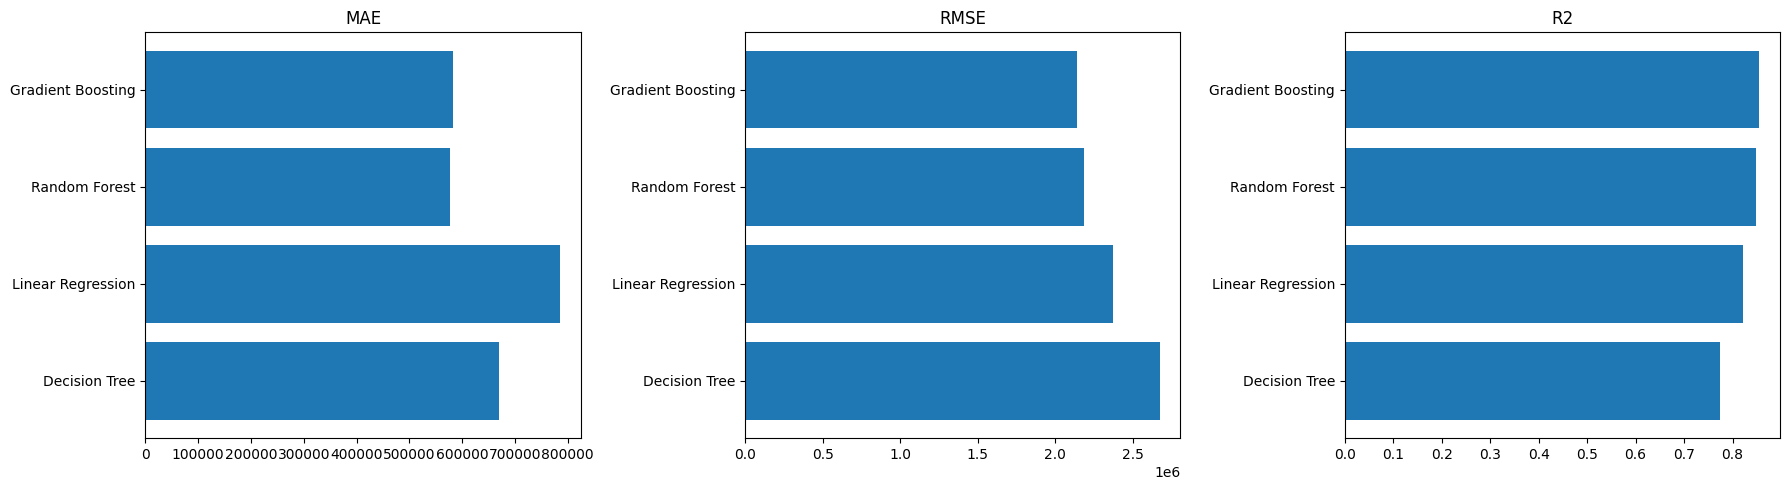

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["MAE", "RMSE", "R2"]
for ax, metric in zip(axes, metrics):
    ax.barh(comparison["Model"], comparison[metric])
    ax.set_title(metric)
    ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 13. Feature Importance (Best Tree-Based Model)

In [18]:
best_model = gb_model if r2_gb >= r2_rf else rf_model
model_name = "Gradient Boosting" if r2_gb >= r2_rf else "Random Forest"

importances = best_model.named_steps["model"].feature_importances_
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(f"Top 15 features -- {model_name}")
display(importance_df.head(15))


Top 15 features -- Gradient Boosting


,feature,importance
6,num__value_12mo_ago,0.884095
5,num__age,0.047671
2,num__height_in_cm,0.007548
4,num__international_goals,0.006454
1,num__current_club_id,0.005579
405,cat__sub_position_Attacking Midfield,0.003935
3,num__international_caps,0.003169
53,cat__country_of_birth_Cote d'Ivoire,0.003140
156,cat__country_of_birth_Portugal,0.002200
279,cat__country_of_citizenship_Ghana,0.001992


## Conclusions

- **Two leak risks were identified and removed**: `highest_market_value_in_eur` (near-duplicate of the target for most active players) and a naive "% change" feature (an algebraic rearrangement of the target).
- In their place, **`value_12mo_ago`** (a genuinely prior valuation) and **recent performance stats** (goals, assists, minutes, cards, all computed from before the reference date) were engineered as honest, leak-free predictors.
- **Gradient Boosting and Random Forest** substantially outperform Linear Regression and a single Decision Tree, reflecting that market value is driven by non-linear relationships and interactions between features that linear models can't capture and single trees tend to overfit.
- **Feature importance shows valuation history dominates** predictions, with age and recent performance contributing meaningfully behind it — consistent with real transfer markets, where value is highly autocorrelated year over year but still responsive to current form.
- **Limitations**: this model doesn't capture injury status, contract situations, transfer rumors, club financial context, or league-quality effects beyond a coarse competition-ID dummy — all promising directions for further feature engineering.

## GRadio

In [19]:
!pip install -q gradio

In [20]:
import gradio as gr

# Use whichever model scored higher on the test set
app_model = gb_model if r2_gb >= r2_rf else rf_model
app_model_name = "Gradient Boosting" if r2_gb >= r2_rf else "Random Forest"

# Build input specs directly from the training data so ranges/choices always match reality
numeric_specs = {}
for col in numerical_features:
    numeric_specs[col] = (
        float(X_train[col].min()),
        float(X_train[col].max()),
        float(X_train[col].median())
    )

categorical_specs = {}
for col in categorical_features:
    # Cap dropdown choices at the 30 most common values plus "Unknown" -- some categorical
    # columns here (e.g. country/club) have hundreds of rare values that would make a dropdown unusable
    top_values = X_train[col].value_counts().head(30).index.tolist()
    if "Unknown" not in top_values:
        top_values.append("Unknown")
    categorical_specs[col] = sorted(top_values)

print(f"App will use: {app_model_name}")
print(f"Numeric inputs: {list(numeric_specs.keys())}")
print(f"Categorical inputs: {list(categorical_specs.keys())}")

App will use: Gradient Boosting
Numeric inputs: ['last_season', 'current_club_id', 'height_in_cm', 'international_caps', 'international_goals', 'age', 'value_12mo_ago', 'has_value_12mo_ago', 'appearances_last_year', 'minutes_last_year', 'goals_last_year', 'assists_last_year', 'yellow_cards_last_year', 'red_cards_last_year', 'goal_contributions_per90', 'has_recent_appearances']
Categorical inputs: ['country_of_birth', 'country_of_citizenship', 'sub_position', 'position', 'foot', 'current_club_domestic_competition_id']


Prediction function and launch

In [27]:
def predict_market_value(*args):
    values = dict(zip(list(numeric_specs.keys()) + list(categorical_specs.keys()), args))

    row = {}
    for col in numerical_features:
        row[col] = values[col]
    for col in categorical_features:
        row[col] = values[col]

    input_df = pd.DataFrame([row])
    prediction = app_model.predict(input_df)[0]
    prediction = max(prediction, 0)  # market value can't be negative

    return f"€{prediction:,.0f}"


# Build Gradio input components dynamically
inputs = []
for col, (lo, hi, default) in numeric_specs.items():
    step = 1 if col in ("last_season", "current_club_id", "international_caps",
                         "appearances_last_year", "goals_last_year", "assists_last_year",
                         "yellow_cards_last_year", "red_cards_last_year",
                         "has_value_12mo_ago", "has_recent_appearances") else None
    inputs.append(gr.Slider(minimum=lo, maximum=hi, value=default, label=col, step=step))

for col, choices in categorical_specs.items():
    inputs.append(gr.Dropdown(choices=choices, value=choices[0], label=col))

demo = gr.Interface(
    fn=predict_market_value,
    inputs=inputs,
    outputs=gr.Textbox(label="Predicted Market Value"),
    title="Tsinanga's Value predictor",
    description=f"Predictions from a {app_model_name} model trained on player characteristics, "
                f"valuation history, and recent performance. Adjust the fields and see the predicted value update.",
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a31335c474e1bc9eb6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [28]:
demo.close()

Closing server running on port: 7863
